# ML based on Medical Data

SEOYEON CHOI  
2026-03-16

[Link](https://www.kaggle.com/datasets/fatemehmohammadinia/heart-attack-dataset-tarik-a-rashid?resource=download)

# About Data

According to the provided information, the medical dataset classifies
either heart attack or none. The gender column in the data is
normalized: the male is set to 1 and the female to 0. The glucose column
is set to 1 if it is \> 120; otherwise, 0. As for the output, positive
is set to 1 and negative to 0.

The dataset has 9 column:

-   Age: The patient’s age
-   Gender: Biological sex of the patient (The male is set to 1 and the
    female to 0)
-   Heart Rate: The number of heartbeats per minute
-   Systolic Blood Pressure: The pressure in arteries when the heart
    contracts
-   Diastolic Blood Pressure: The pressure in arteries between
    heartbeats
-   Blood Sugar: The patient’s blood glucose level
-   Ck-mb: A cardiac enzyme released during heart muscle damage
    -   심장 근육에 존재하는 효소로, 심장 근육이 손상되면 방출된다.
-   Troponin:A highly specific protein biomarker for heart muscle injury
    -   심장 근육 수축에 관여하는 단백질
-   Result: The outcome label indicating whether or not the patient
    experienced a heart attack

# Import

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind

# Data

In [5]:
df = pd.read_csv("../../../../delete/Medicaldataset.csv")
df.head()

In [8]:
df['Result'] = df['Result'].map({'negative': 0, 'positive': 1})

In [9]:
df['Result'].value_counts()

# EMA

-   Age

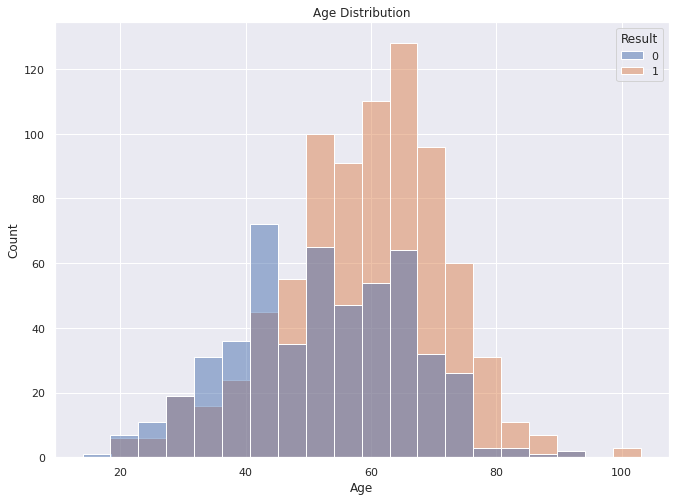

In [22]:
sns.histplot(data=df, x='Age', hue='Result', bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

-   Gender

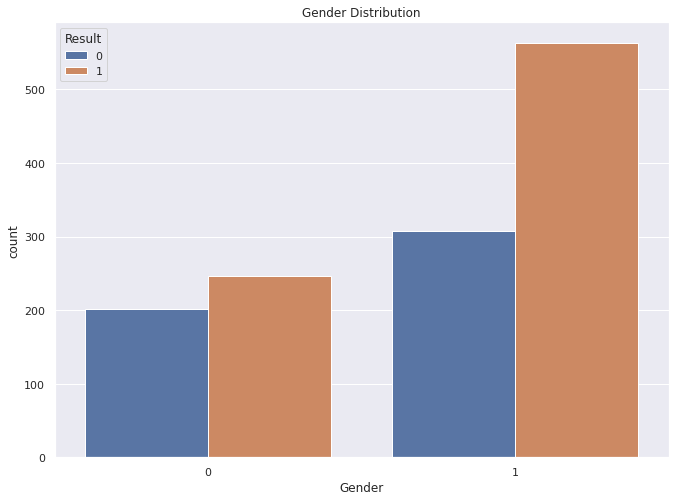

In [28]:
sns.countplot(x='Gender', hue='Result', data=df)
plt.title("Gender Distribution")

-   Data distribution check

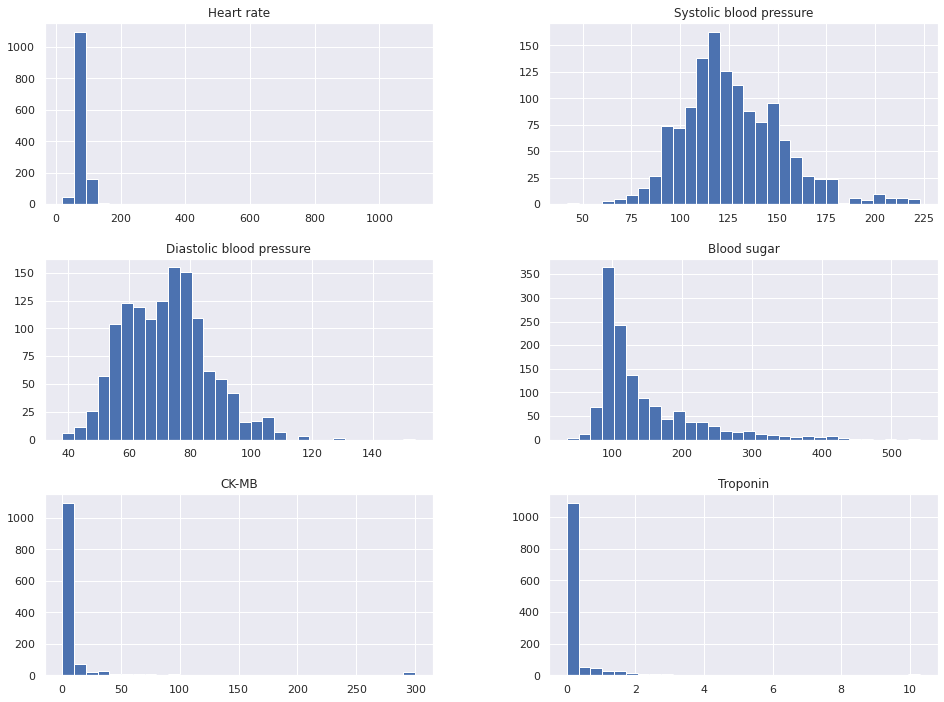

In [45]:
cols = ['Heart rate','Systolic blood pressure','Diastolic blood pressure','Blood sugar','CK-MB','Troponin']
df[cols].hist(figsize=(16,12),bins=30);

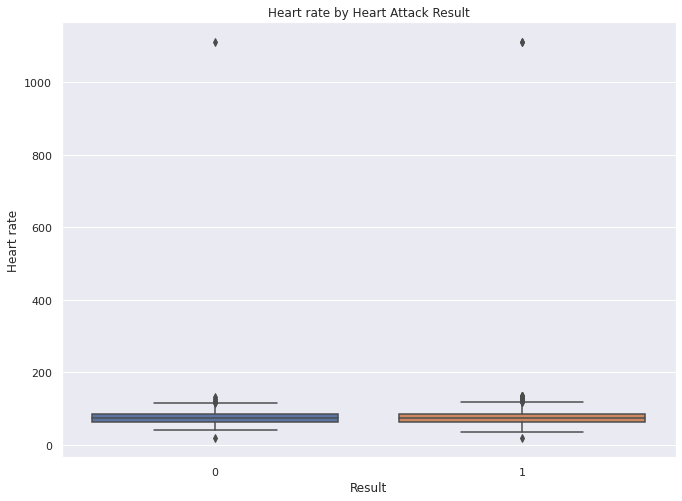

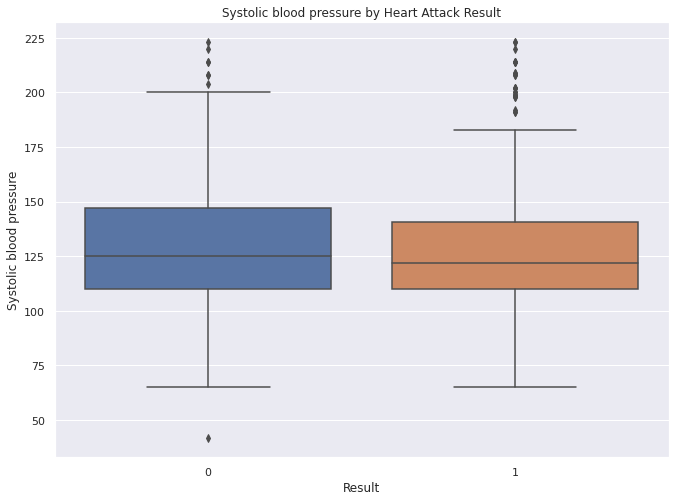

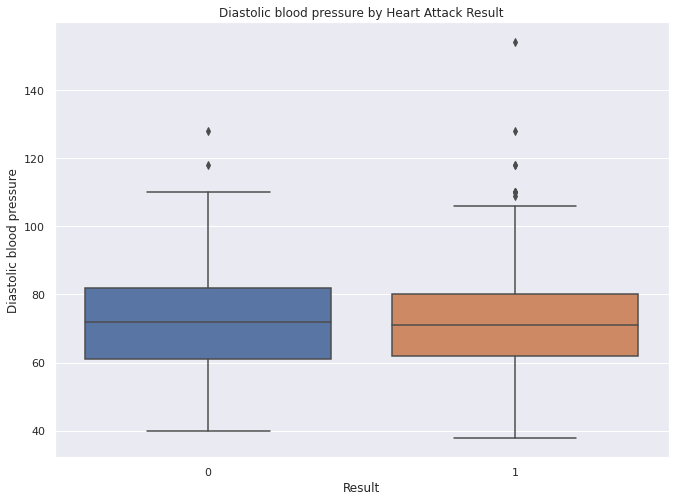

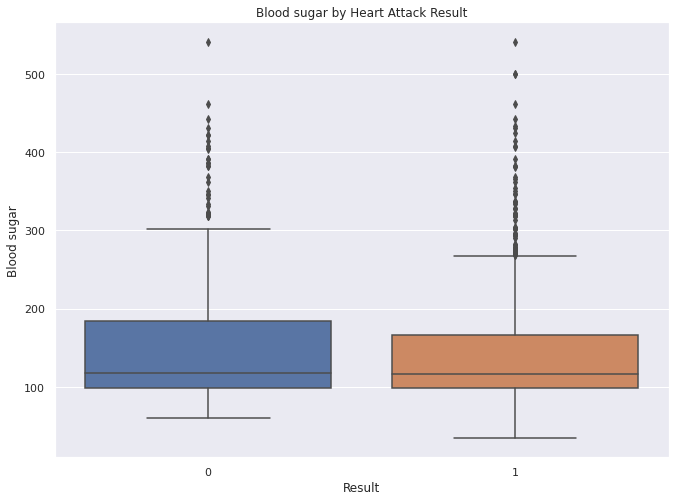

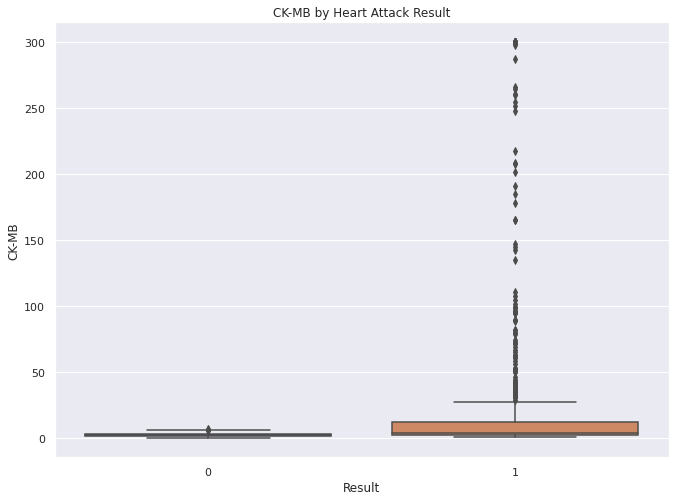

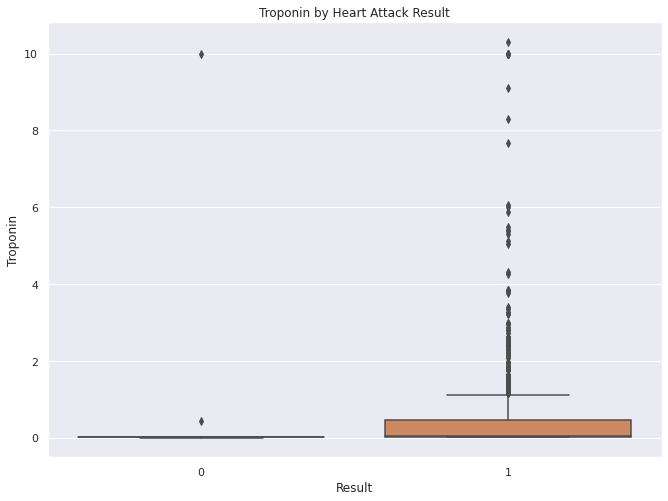

In [33]:
for col in cols:
    sns.boxplot(x='Result', y=col, data=df)
    plt.title(col + " by Heart Attack Result")
    plt.show()

-   ttest

In [54]:
for col in cols:
    g0 = df[df['Result']==0][col]
    g1 = df[df['Result']==1][col]

    t,p = ttest_ind(g0,g1)
    print(col, "p-value:", round(p,2))

Heart rate p-value: 0.8
Systolic blood pressure p-value: 0.45
Diastolic blood pressure p-value: 0.73
Blood sugar p-value: 0.23
CK-MB p-value: 0.0
Troponin p-value: 0.0

-   data outliers

Values outside physiologically plausible ranges (e.g., heart rate \> 250
bpm) were treated as data entry errors and set to missing.

In [60]:
df['Heart rate'].describe()

In [61]:
df.sort_values('Heart rate', ascending=False).head(5)

In [62]:
df = df[df['Heart rate'] < 250]

In [68]:
df.sort_values('CK-MB', ascending=False).head(20)